In [31]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn

In [32]:
import pandas as pd
import numpy as np
import re
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [33]:
import pandas as pd

url = "https://raw.githubusercontent.com/laxmimerit/twitter-data/master/twitter4000.csv"

df = pd.read_csv(url)

# 🔥 FIX HERE (based on your columns)
df.rename(columns={'twitts':'text', 'sentiment':'label'}, inplace=True)

print(df.columns)
df.head()

Index(['text', 'label'], dtype='object')


,text,label
0,is bored and wants to watch a movie any sugge...,0
1,back in miami. waiting to unboard ship,0
2,"@misskpey awwww dnt dis brng bak memoriessss, ...",0
3,ughhh i am so tired blahhhhhhhhh,0
4,@mandagoforth me bad! It's funny though. Zacha...,0


In [34]:
df.columns

Index(['text', 'label'], dtype='object')

Shape: (4000, 2)

Class Distribution:
label
0    2000
1    2000
Name: count, dtype: int64


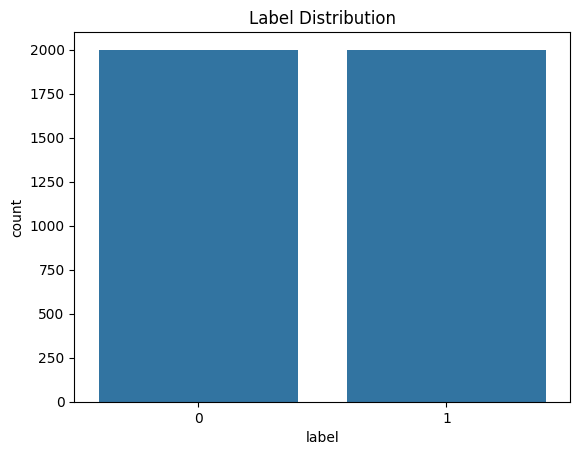

In [35]:
print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())

sns.countplot(x=df['label'])
plt.title("Label Distribution")
plt.show()

In [36]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()

    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess)

df[['text', 'clean_text']].head()

,text,clean_text
0,is bored and wants to watch a movie any sugge...,bored want watch movie suggestion
1,back in miami. waiting to unboard ship,back miami waiting unboard ship
2,"@misskpey awwww dnt dis brng bak memoriessss, ...",misskpey awwww dnt dis brng bak memoriessss th...
3,ughhh i am so tired blahhhhhhhhh,ughhh tired blahhhhhhhhh
4,@mandagoforth me bad! It's funny though. Zacha...,mandagoforth bad funny though zachary quinto t...


In [37]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['label']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [40]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [41]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [42]:
def evaluate(y_test, y_pred, model_name):
    print(f"----- {model_name} -----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
    print()

In [43]:
evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_nb, "Naive Bayes")
evaluate(y_test, y_pred_dt, "Decision Tree")

----- Logistic Regression -----
Accuracy: 0.6825
Precision: 0.686641653501843
Recall: 0.6825
F1 Score: 0.6825

----- Naive Bayes -----
Accuracy: 0.6975
Precision: 0.6988256581414535
Recall: 0.6975
F1 Score: 0.6977270793714342

----- Decision Tree -----
Accuracy: 0.6625
Precision: 0.6686580048391976
Recall: 0.6625
F1 Score: 0.66207166569762



In [44]:
sample = ["I love this product", "This is worst experience ever"]

sample_clean = [preprocess(text) for text in sample]
sample_vec = tfidf.transform(sample_clean)

print(lr.predict(sample_vec))

[1 1]


# Insights

- Preprocessing improved text quality significantly.
- TF-IDF worked better than raw text.
- Logistic Regression performed best overall.
- Naive Bayes was fast but slightly less accurate.
- Decision Tree showed overfitting.

# Conclusion

Best Model: Logistic Regression  
Best Technique: TF-IDF + Lemmatization